<a href="https://colab.research.google.com/github/Thawin2551/python/blob/main/data_ml_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recap Data analytics Deep Learning and ML Before Interviews

In [188]:
import pandas as pd
import numpy as np

In [189]:
df = pd.read_csv("/content/marketing_campaign_data_messy.csv")
print(f"Load Dataset: {df.shape[0]} rows, {df.shape[1]} column \n")

Load Dataset: 2020 rows, 12 column 



In [190]:
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


In [191]:
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower()
print("\n Fix string strip and convert to lower case \n")
print(df.columns.tolist(), "\n")

df

[' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks', 'Campaign_Tag']

 Fix string strip and convert to lower case 

['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel', 'impressions', 'clicks', 'spend', 'conversions', 'active', 'clicks', 'campaign_tag'] 



,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,clicks,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


In [192]:
# Convert currency and type of data

clean_spend = df['spend'].astype(str).str.contains(r'\$')
print(df.loc[clean_spend,['campaign_id', 'spend']].head(3))

df['spend'] = df['spend'].astype(str).str.replace(r'[^\d.-]', '', regex=True)
df['spend'] = pd.to_numeric(df['spend'])

print("AFTER CLEANING COLUMN SPEND REMOVE $ SIGN")
print(type(df['spend']))
df.head()

   campaign_id     spend
0    CMP-00001   $102.82
21   CMP-00022   $2428.4
22   CMP-00023  $4726.22
AFTER CLEANING COLUMN SPEND REMOVE $ SIGN
<class 'pandas.core.series.Series'>


,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,clicks,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [193]:
# Fix Wrong Channel Spelling

print(df['channel'].unique())

cleanup_channel_map = {
    'Facebok' : 'Facebook',
    'Insta_gram' : 'Instagram',
    'E-mail' : 'Email',
    'Gogle' : 'Google Ads',
    'Tik_Tok' : 'TikTok',
    'N/A' : np.nan
}

df['channel'] = df['channel'].replace(cleanup_channel_map)
df['channel'].unique()

df

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']


,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,clicks,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.00,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.50,591.0,Yes,NaN,FA


In [194]:
# Clean Up Boolean in active columns

print(df['active'].unique())
print(df['active'].head())

bool_map_clean = {
  'Yes' : True,
  '1' : True,
  1 : True,
  'Y' : True,

  'No' : False,
  '0' : False,
    0 : False,
  'N' : False
}

df['active'] = df['active'].map(bool_map_clean).fillna(False).astype(bool)
print("AFTER CLEAN")
print(df['active'].unique())
print(df['active'].head())

['Y' '0' 'No' 'True' 'Yes' '1' 'False']
0       Y
1       0
2      No
3    True
4     Yes
Name: active, dtype: object
AFTER CLEAN
[ True False]
0     True
1    False
2    False
3    False
4     True
Name: active, dtype: bool


/tmp/ipython-input-3670673512.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['active'] = df['active'].map(bool_map_clean).fillna(False).astype(bool)


In [195]:
# Fix Date
print(df["start_date"].dtype)

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce') # coerce บังคับให้เป็น datetime
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

print("start_date type: ", df['start_date'].dtype)
print("end_date type: ", df['end_date'].dtype)

object
start_date type:  datetime64[ns]
end_date type:  datetime64[ns]


In [196]:
# Remove Duplicate clicks column
df = df.loc[:, ~df.columns.duplicated()]

In [197]:
df

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,NaT,2023-11-03,TikTok,55886,2019,2180.38,135.0,False,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA
...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31,2023-11-13,TikTok,30592,586,503.95,77.0,True,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01,2023-09-26,Google Ads,20097,897,1641.00,162.0,False,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09,2023-02-21,Instagram,33254,1117,883.82,214.0,False,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30,2023-04-27,Facebook,68728,2960,4198.50,591.0,True,FA


In [198]:
# Analyze Feature Column Between CLICK VS IMPRESSION Which is Important ?

impossible_mask = df['clicks'] > df['impressions']
print(df.loc[impossible_mask,['campaign_id', 'impressions', 'clicks']].head(3))

Empty DataFrame
Columns: [campaign_id, impressions, clicks]
Index: []


In [199]:
# Logic start_date vs end_date

time_travel_mask = df['end_date'] < df['start_date']
print(df.loc[time_travel_mask, ['campaign_id', 'start_date', 'end_date']].head())

# as you can see some column between start and end date has incorrect data
# next we will assume end_date + 30 days within end_date that < start_date

df.loc[time_travel_mask, 'end_date'] = df.loc[time_travel_mask, 'start_date'] + pd.Timedelta(days=30)
print('\n FIX END_DATE \n')
print(df.loc[time_travel_mask, ['campaign_id', 'start_date', 'end_date']].head())

    campaign_id start_date   end_date
23    CMP-00024 2023-05-06 2023-05-01
54    CMP-00055 2023-09-01 2023-08-27
71    CMP-00072 2023-02-01 2023-01-27
156   CMP-00157 2023-12-06 2023-12-01
200   CMP-00201 2023-01-11 2023-01-06

 FIX END_DATE 

    campaign_id start_date   end_date
23    CMP-00024 2023-05-06 2023-06-05
54    CMP-00055 2023-09-01 2023-10-01
71    CMP-00072 2023-02-01 2023-03-03
156   CMP-00157 2023-12-06 2024-01-05
200   CMP-00201 2023-01-11 2023-02-10


In [200]:
# HANDLING outliner use IQR

Q1 = df['spend'].quantile(0.25)
Q3 = df['spend'].quantile(0.75)

Inter_Quantile_Range = Q3 - Q1
upper_fence = Q3 + (1.5 * Inter_Quantile_Range)
# lower_fence = Q1 - (1.5 * Inter_Quantile_Range)

outliner_mask = (df['spend'] > upper_fence)
print(df.loc[outliner_mask, ['campaign_id', 'spend']].head())

print("FIX Outliner")
df.loc[outliner_mask, 'spend'] = upper_fence
print(df.loc[outliner_mask, ['campaign_id', 'spend']].head())

    campaign_id    spend
57    CMP-00058  5719.84
70    CMP-00071  5951.42
119   CMP-00120  7471.52
124   CMP-00125  6449.30
130   CMP-00131  6688.28
FIX Outliner
    campaign_id    spend
57    CMP-00058  5620.96
70    CMP-00071  5620.96
119   CMP-00120  5620.96
124   CMP-00125  5620.96
130   CMP-00131  5620.96


In [204]:
print(df['campaign_name'].head())

df['season'] = df['campaign_name'].str.extract(r'Q\d_([^_]+)_')

print("Extract Feature")
print(df[['campaign_name', 'season']].head())

0         Q4_Summer_CMP-00001
1         Q1_Launch_CMP-00002
2         Q3_Winter_CMP-00003
3    Q1_BlackFriday_CMP-00004
4         Q2_Winter_CMP-00005
Name: campaign_name, dtype: object
Extract Feature
              campaign_name       season
0       Q4_Summer_CMP-00001       Summer
1       Q1_Launch_CMP-00002       Launch
2       Q3_Winter_CMP-00003       Winter
3  Q1_BlackFriday_CMP-00004  BlackFriday
4       Q2_Winter_CMP-00005       Winter


# Practice 2 Data analytics and machine learning


In [197]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
import tqdm

if not sys.warnoptions:
  warnings.simplefilter("ignore")
seed = np.random.seed(42)

In [198]:
df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')
print(f"Number of rows: {df.shape[0]} and column: {df.shape[1]}")
df.head(10)

Number of rows: 2240 and column: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [200]:
print(f"\n The total number of rows after removing nan values: {len(df)} \n")
df.dropna()


 The total number of rows after removing nan values: 2240 



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [201]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
print(df['Dt_Customer'].dtype)
dates = []
for i in df['Dt_Customer']:
  i = i.date()
  dates.append(i)
# New Dates after re-arrange
print(f"The newest customer that enrollment: {max(dates)}")
print(f"The oldest customer that enrollment: {min(dates)}")

print(df.head(10))
print(f" \n rows: {df.shape[0]}")

datetime64[ns]
The newest customer that enrollment: 2014-06-29
The oldest customer that enrollment: 2012-07-30
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   
5  7446        1967      Master       Together  62513.0        0         1   
6   965        1971  Graduation       Divorced  55635.0        0         1   
7  6177        1985         PhD        Married  33454.0        1         0   
8  4855        1974         PhD       Together  30351.0        1         0   
9  5899        1950         PhD       Together   5648.0        1         1   

  Dt_Customer  Recency  MntWin

Check dtype of Dt_Customer

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [203]:
# Create New Feature (Column) Customer_For
days = []
d1 = max(dates) # Taking the newest date of Customer
for i in dates:
  delta = d1 - i
  days.append(delta)
df['Customer_For'] = days # Number of days the past through the day customer enroll
df['Customer_For'] = pd.to_numeric(df["Customer_For"], errors="coerce")
df.dropna()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,57283200000000000
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,9763200000000000
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,26956800000000000
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,12009600000000000
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,13910400000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,3,11,0,32918400000000000
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,1,0,0,3,11,0,1641600000000000
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,1,0,0,0,0,3,11,0,13392000000000000
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,3,11,0,13478400000000000


In [204]:
print(f"Total categories in Marital_Status {df['Marital_Status'].value_counts()} \n")
print(f"Total categories in Education {df['Education'].value_counts()}")
df

Total categories in Marital_Status Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in Education Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,57283200000000000
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,9763200000000000
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,26956800000000000
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,12009600000000000
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,13910400000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,3,11,0,32918400000000000
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,1,0,0,3,11,0,1641600000000000
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,1,0,0,0,0,3,11,0,13392000000000000
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,3,11,0,13478400000000000


In [205]:
# Feature Engineering
# Extract Date

df['Age'] = 2025 - df['Year_Birth']

# Sum of Columns Mnt wines fish etc.
sum_spent = df['MntFishProducts'] + df['MntFruits'] + df['MntGoldProds'] + df['MntMeatProducts'] + df['MntSweetProducts'] + df['MntWines']
df['Spent'] = sum_spent

# Refer frome Marital_Status COlumn
df['Living_With'] = df['Marital_Status'].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Absurd" : "Alone",
    "Widow" : "Alone",
    "YOLO" : "Alone"
})

# Feature total children in the house
df['Children'] = df['Kidhome'] + df['Teenhome']

# Member in the house
df['Family_Size'] = df['Children'].replace({'Alone': 1, 'Partner': 2}) + df['Children']

#Feature Parenthood Check
df['Is_Parent'] = np.where(df.Children > 0, 1, 0) # if Children Col. > 0 Will be 1 if false Would be 0

# Arrange A Education Group
df['Education'] = df['Education'].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})

# Rename Mnt Column
# df = df.rename(columns={
#     "MntWines" : "Wines",
#     "MntFruits" : "Fruits",
#     "MntFishProducts" : "Fish",
#     "MntMeatProducts" : "Meat",
#     "MntSweetProducts" : "Sweet",
#     "MntGoldProds" : "Golds"
# })

# Drop Columns that Already Extracted. Ex. Age (Remove Year_Birth) Remove Id because it's not nescessary while training model
drop_col = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
df = df.drop(drop_col, axis=1) # axis 1 = column, axis 0 = row
print(df)

         Education   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0         Graduate  58138.0        0         0       58       635         88   
1         Graduate  46344.0        1         1       38        11          1   
2         Graduate  71613.0        0         0       26       426         49   
3         Graduate  26646.0        1         0       26        11          4   
4     Postgraduate  58293.0        1         0       94       173         43   
...            ...      ...      ...       ...      ...       ...        ...   
2235      Graduate  61223.0        0         1       46       709         43   
2236  Postgraduate  64014.0        2         1       56       406          0   
2237      Graduate  56981.0        0         0       91       908         48   
2238  Postgraduate  69245.0        0         1        8       428         30   
2239  Postgraduate  52869.0        1         1       40        84          3   

      MntMeatProducts  MntFishProducts 

# Rename Mnt Columns

In [206]:
#  Rename Mnt Column
df = df.rename(columns={
     "MntWines" : "Wines",
     "MntFruits" : "Fruits",
     "MntFishProducts" : "Fish",
     "MntMeatProducts" : "Meat",
     "MntSweetProducts" : "Sweet",
     "MntGoldProds" : "Golds"
 })

df.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweet,Golds,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2.240000e+03,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,...,0.064286,0.013393,0.009375,0.149107,3.054950e+16,56.194196,605.798214,0.950446,1.900893,0.715179
std,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,...,0.245316,0.114976,0.096391,0.356274,1.746339e+16,11.984069,602.249288,0.751803,1.503606,0.451430
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,29.000000,5.000000,0.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.561680e+16,48.000000,68.750000,0.000000,0.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,55.000000,396.000000,1.000000,2.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,66.000000,1045.500000,1.000000,2.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,132.000000,2525.000000,3.000000,6.000000,1.000000


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

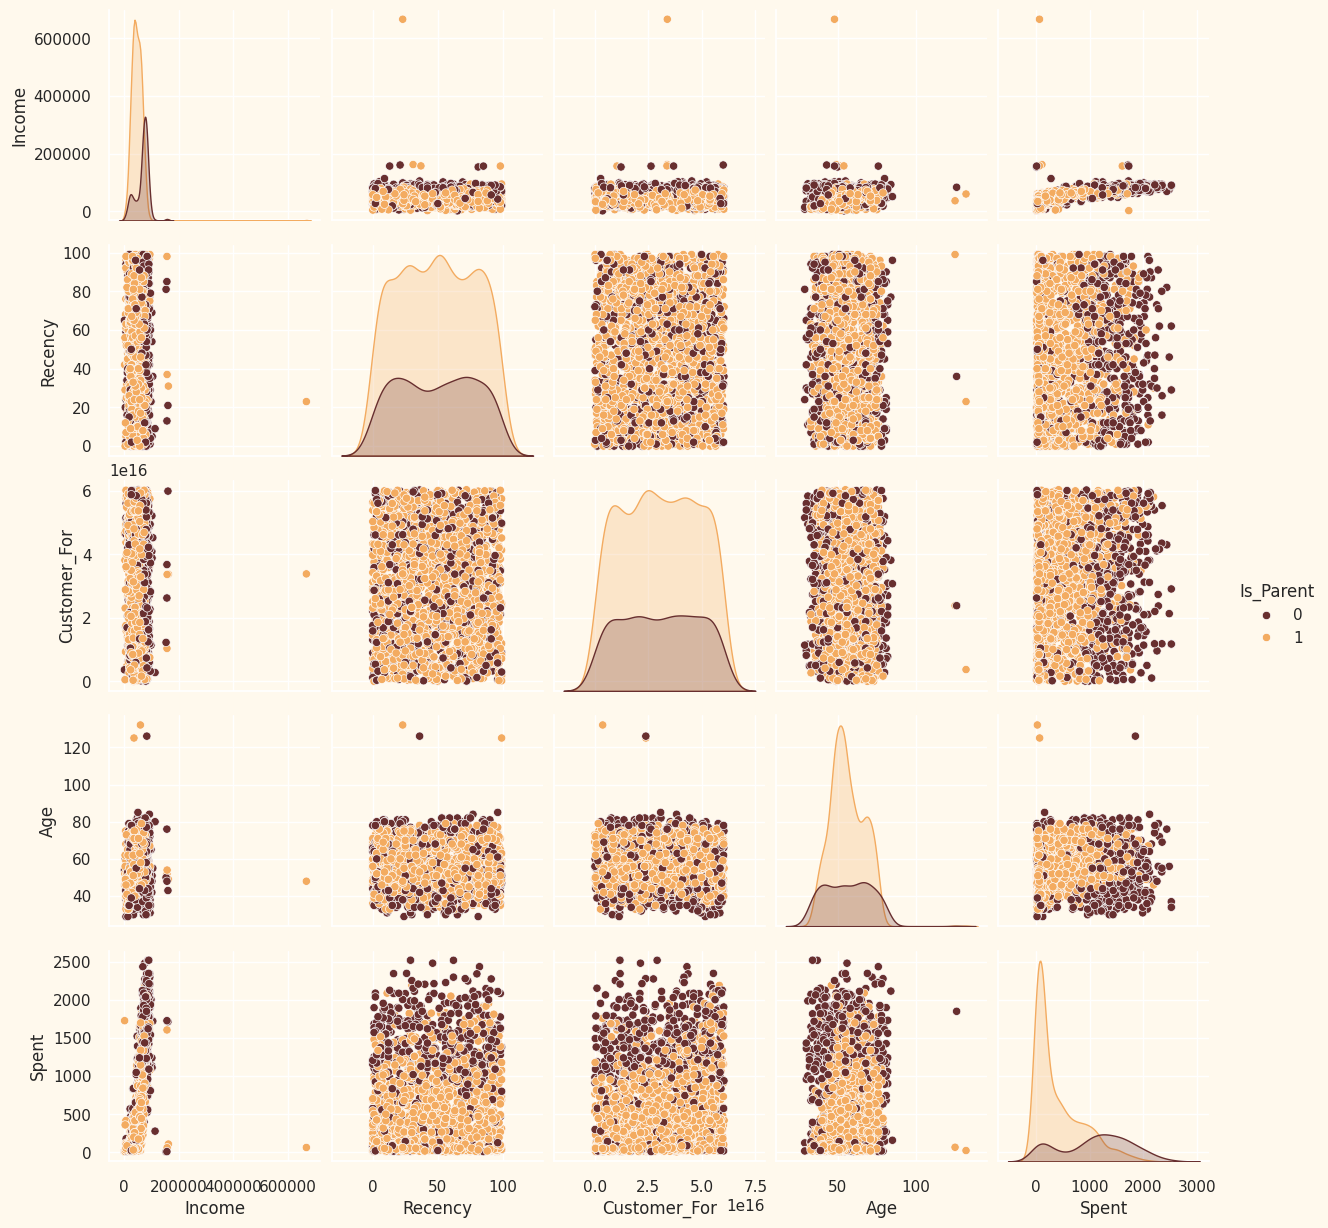

In [207]:
#To plot some selected features

#Setting up colors preferences
sns.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])

#Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(df[To_Plot], hue= "Is_Parent",palette= (["#682F2F","#F3AB60"]))

#Plot
plt.show()

In [208]:
#Dropping Outliner by fix or set at income and age
df = df[(df['Age']) < 90]
df = df[(df['Income'] < 500000)]
print(f"The total of data-points after removing oultiners are: {len(df)}")

The total of data-points after removing oultiners are: 2212


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   object 
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweet                2212 non-null   int64  
 10  Golds                2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [210]:
# Check Data which column should transform categorical values to numeric (LabelEncoder)
# For what? Because if some dtype are string it's hardly to predict
s = (df.dtypes == "object")
f = (df.dtypes == "float64")
i = (df.dtypes == "int64")
float_cols = list(s[f].index)
object_cols = list(s[s].index)
int_cols = list(s[i].index)

print(f"Float variables: {float_cols}")
print(f"Integer variables: {int_cols}")
print(f"Categorical variables: {object_cols}")
print("Total Columns:" ,(len(float_cols) + len(object_cols) + len(int_cols)))

Float variables: ['Income']
Integer variables: ['Kidhome', 'Teenhome', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweet', 'Golds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Customer_For', 'Age', 'Spent', 'Children', 'Family_Size', 'Is_Parent']
Categorical variables: ['Education', 'Living_With']
Total Columns: 30


In [211]:
# Transform String (Categorical) to Integer (Numeric)
LE = LabelEncoder()
for i in object_cols:
  # Education and Living_With will transform to numeric Number
  df[i] = df[[i]].apply(LE.fit_transform)
print("All Features are now numerical")

All Features are now numerical


In [212]:
df.info()
print("\n")
print(f"Education Data type: {df["Education"].dtype}")
print(f"Living With Data type: {df["Living_With"].dtype}")

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweet                2212 non-null   int64  
 10  Golds                2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [213]:
#Scaling Data

dataset = df.copy()
# Some columns isn't nescessary to use for traning
cols_delete = [
  'AcceptedCmp1',
  'AcceptedCmp2',
  'AcceptedCmp3',
  'AcceptedCmp4',
  'AcceptedCmp5',
  'Complain',
  'Response'
]
dataset = dataset.drop(cols_delete, axis=1)

#Scaling to make sure that some columns like income and age is not much higher
scaler = StandardScaler()
scaler.fit(dataset)
# Create New dataset
scaled_dataset = pd.DataFrame(scaler.transform(dataset), columns=dataset.columns)
print("ALL Featured Are scaled")

ALL Featured Are scaled


In [214]:
dataset.info()
print("\n After we scaled dataset we will get float type that between -1 to 1 \n")
scaled_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweet                2212 non-null   int64  
 10  Golds                2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [215]:
print("\n We will use this dataset to modelling ml \n")
scaled_dataset.head()


 We will use this dataset to modelling ml 



,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweet,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,1.416691,-1.264598,-1.264598,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,1.416691,1.404572,1.404572,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,-0.048349,-1.264598,-1.264598,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,-0.048349,0.069987,0.069987,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,-0.048349,0.069987,0.069987,0.632456


 After we got many features and corelation between data like education and income
 We will chose 1 column or essentital data to use for training model for reduce redundant feature
 # ( PCA Principal Component Analysis )

 เอาไว้ลด dimension ของ data เยอะ ๆ แต่ยังคงข้อมูลไว้อยู่โดยการสร้างตัวแปรใหม่มาเก็บข้อมูลที่ลด dimension ไว้

In [188]:
# Assign a PCA to reduce Dimensionality of Data
pca = PCA(n_components = 3)
pca.fit(scaled_dataset)
PCA_Dataset = pd.DataFrame(pca.transform(scaled_dataset), columns =["col1", "col2", "col3"])
PCA_Dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,3.854662e-17,2.900485,-5.948333,-2.565253,-0.785103,2.411770,7.587126
col2,2212.0,-3.212219e-17,1.726051,-4.213919,-1.374841,-0.137259,1.285848,6.110711
col3,2212.0,5.300161e-17,1.225688,-3.360260,-0.861140,0.002647,0.858623,6.396891


แทนที่เราจะลดข้อมูลที่เรามี เราใช้เทคนิค PCA ในการลดมิติของข้อมูล แล้วทำ Data Visualization จาก Matplotlib เพื่อดู Relationship ของข้อมูลทั้ง 3 columns (x, y, z)

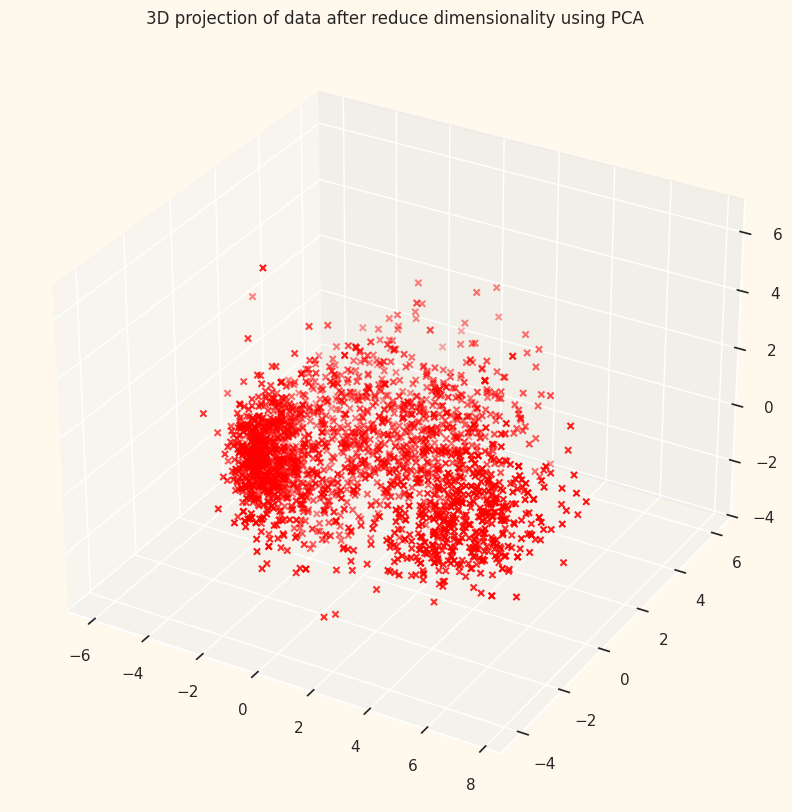

In [221]:
x = PCA_Dataset["col1"]
y = PCA_Dataset["col2"]
z = PCA_Dataset["col3"]

#Plot
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="red", marker="x")
ax.set_title("3D projection of data after reduce dimensionality using PCA")
plt.show()

Elbow method to determine the number of cluster to be formed


<bound method Visualizer.show of KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=50), k=50)>

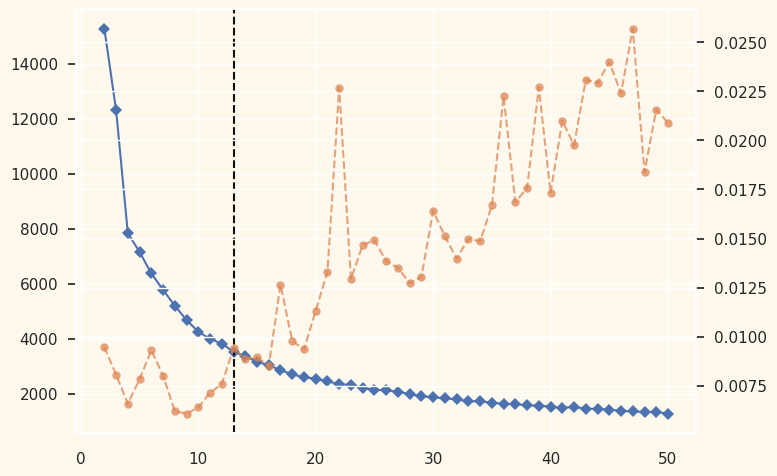

In [229]:
# using elbow method to arrange cluster group for finding k
# Example เฉยๆ
print("Elbow method to determine the number of cluster to be formed")
Elbow_M = KElbowVisualizer(KMeans(), k=50)
Elbow_M.fit(PCA_Dataset)
Elbow_M.show

In [230]:
#Initiating the Agglomerative Clustering model
AC = AgglomerativeClustering(n_clusters=4)
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_Dataset[['col1', 'col2', 'col3']])
PCA_Dataset["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
df["Clusters"]= yhat_AC # Changed from `data` to `df` for consistency with processed data

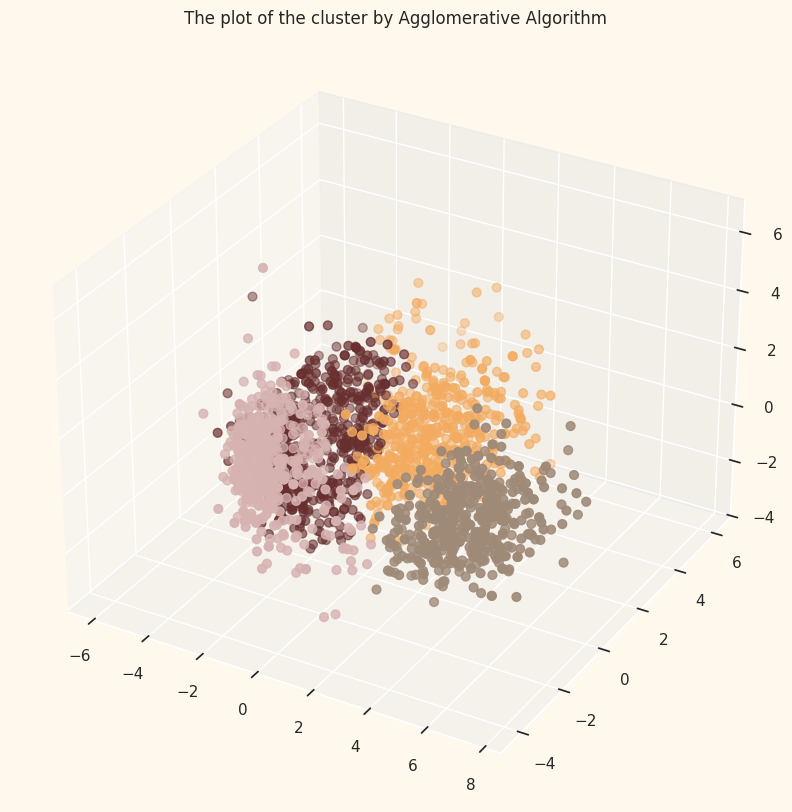

In [233]:
#Plotting the clusters
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, projection="3d", label="bla")
ax.scatter(x, y, z, s=40, c=PCA_Dataset["Clusters"], marker="o", cmap=cmap)
ax.set_title("The plot of the cluster by Agglomerative Algorithm")
plt.show()

/tmp/ipython-input-1434342898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=df["Clusters"], palette= pal)


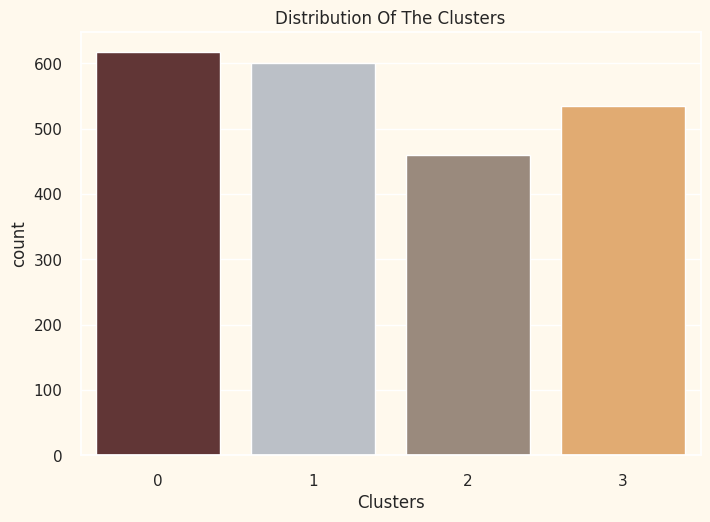

In [235]:
#Plotting countplot of clusters
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
pl = sns.countplot(x=df["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

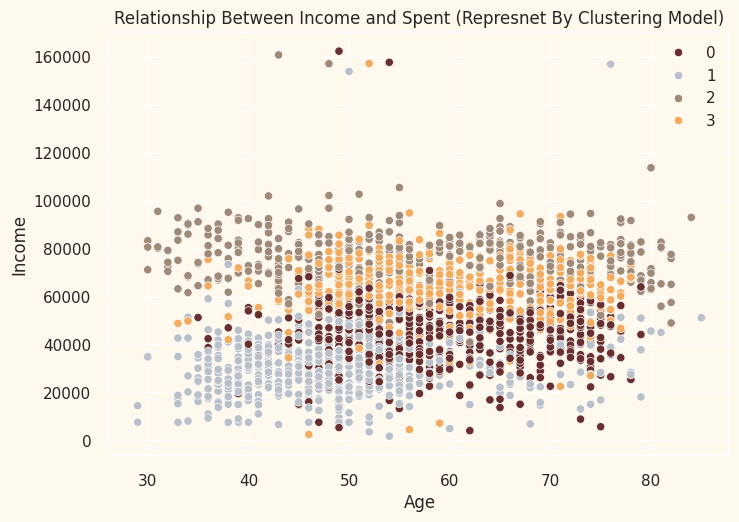

In [243]:
pl = sns.scatterplot(data = df, x = df['Age'], y = df['Income'], hue=df["Clusters"], palette=pal)
pl.set_title("Relationship Between Income and Spent (Represnet By Clustering Model)")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 55.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 70.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipython-input-3955809209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(x=df["Clusters"], y=df["Spent"], palette=pal)
/usr/local/lib/python3.12/dist-packages/seaborn/categ

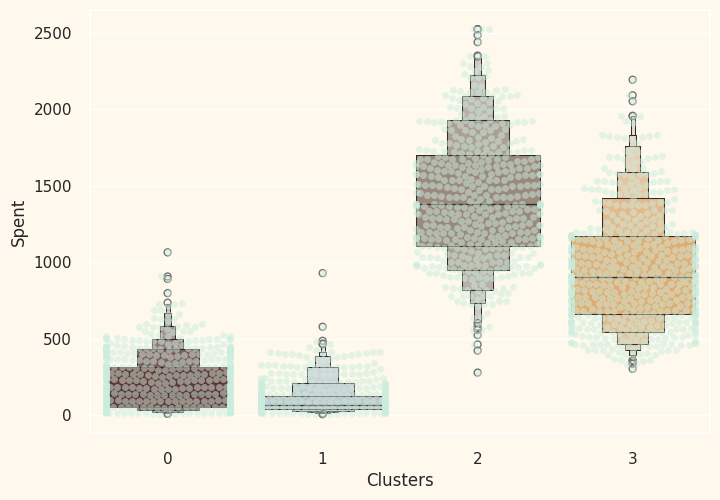

In [244]:
plt.figure()
pl=sns.swarmplot(x=df["Clusters"], y=df["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=df["Clusters"], y=df["Spent"], palette=pal)
plt.show()

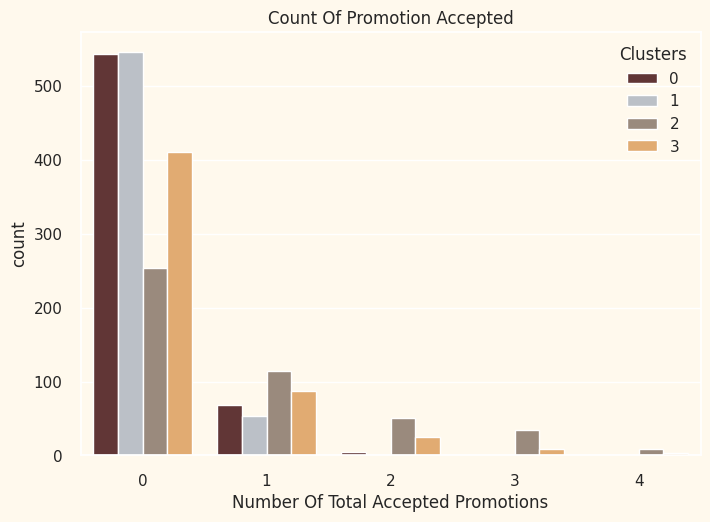

In [245]:
#Creating a feature to get a sum of accepted promotions
df["Total_Promos"] = df["AcceptedCmp1"]+ df["AcceptedCmp2"]+ df["AcceptedCmp3"]+ df["AcceptedCmp4"]+ df["AcceptedCmp5"]
#Plotting count of total campaign accepted.
plt.figure()
pl = sns.countplot(x=df["Total_Promos"],hue=df["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

<Figure size 800x550 with 0 Axes>

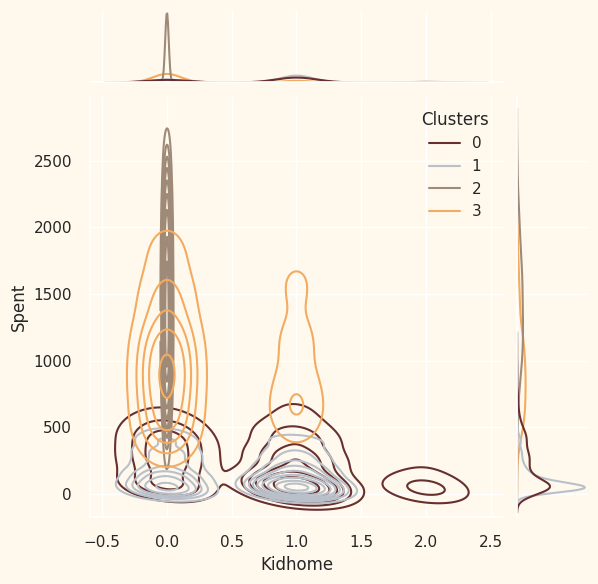

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 800x550 with 0 Axes>

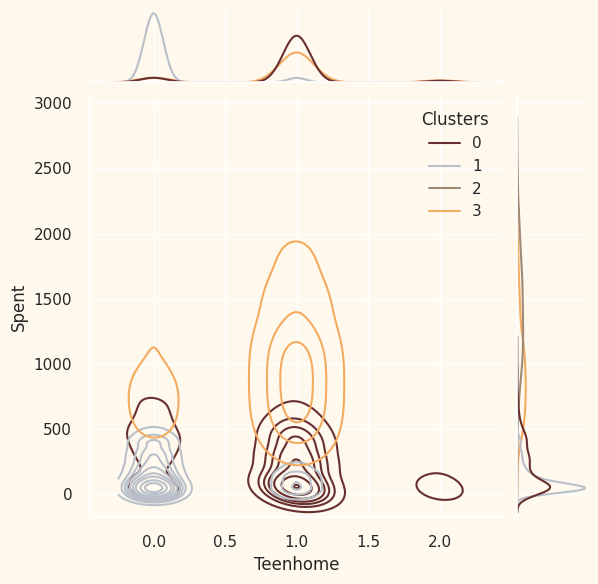

<Figure size 800x550 with 0 Axes>

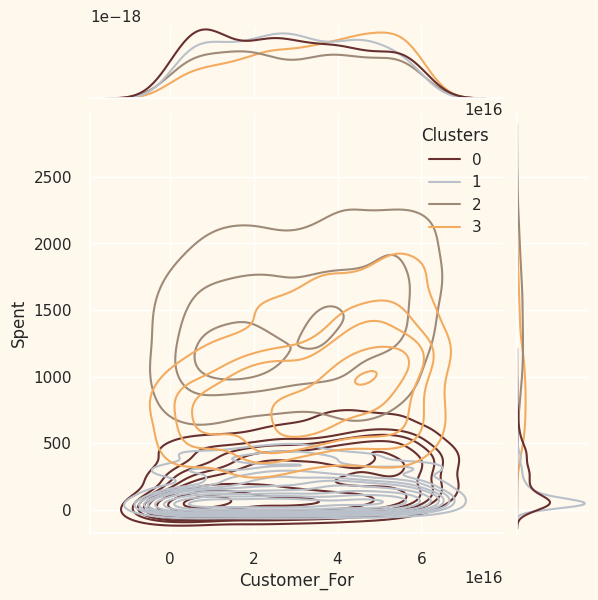

<Figure size 800x550 with 0 Axes>

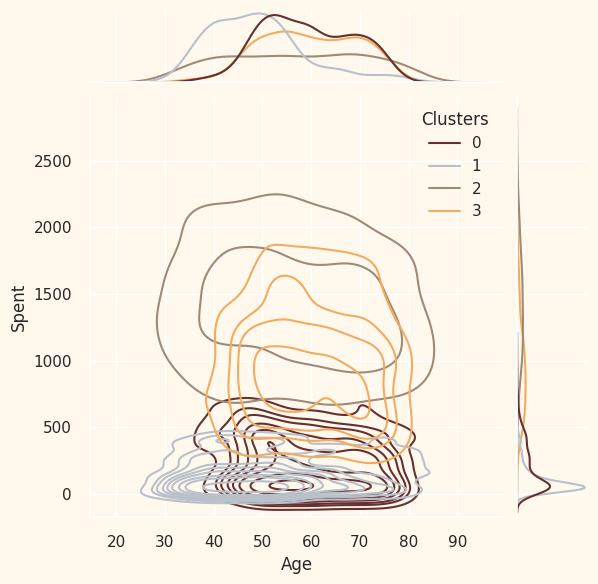

<Figure size 800x550 with 0 Axes>

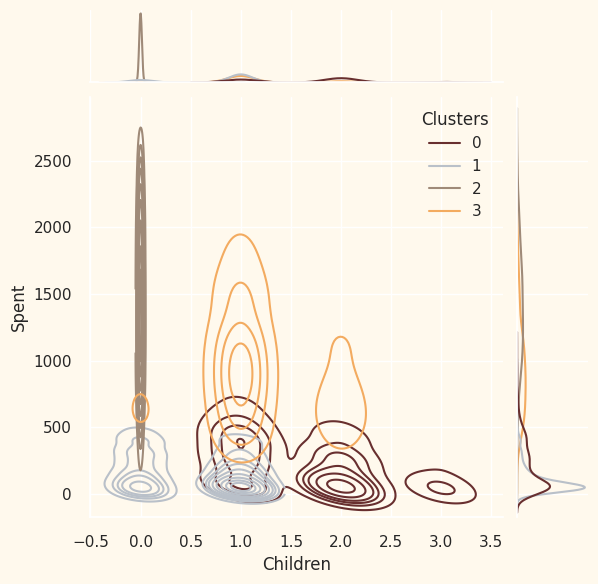

<Figure size 800x550 with 0 Axes>

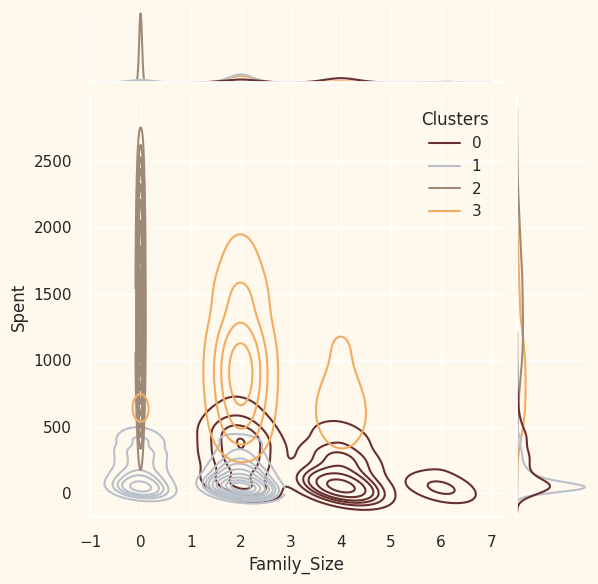

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 800x550 with 0 Axes>

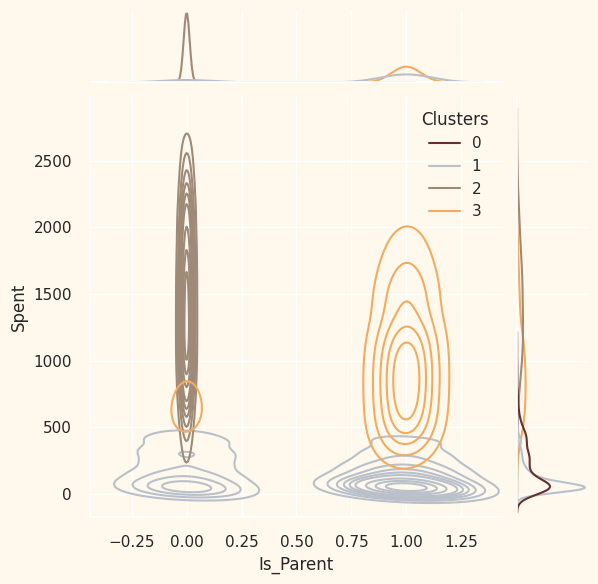

<Figure size 800x550 with 0 Axes>

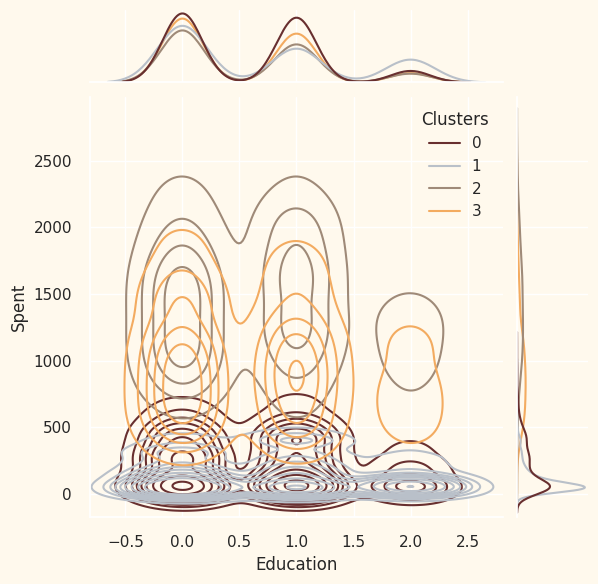

<Figure size 800x550 with 0 Axes>

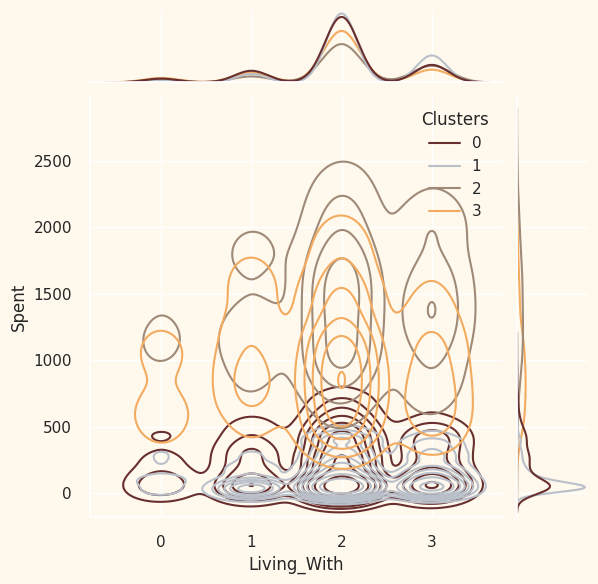

In [247]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=df[i], y=df["Spent"], hue =df["Clusters"], kind="kde", palette=pal)
    plt.show()

In [248]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
